In [16]:
from jax import numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from flax import nnx
from jax import random
import jax

In [ ]:
true_w = jnp.array([2, -3])
true_b = 4.2

Rngs = nnx.Rngs(0)

def generate_synthetic_data(w, b):
    examples = 500
    ## 500 examples 2 features
    X = Rngs.normal((examples, 2))
    y = jnp.einsum("ef,f->e", X, w) + b
    y += Rngs.normal((examples,))*0.01

    return X, y

features, labels = generate_synthetic_data(true_w, true_b)

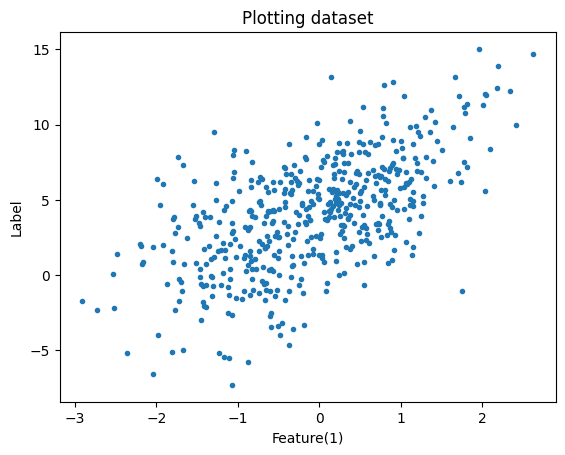

In [18]:
f = np.array(features[:, 0])
l = np.array(labels)

# Plot the data
plt.plot(f, l, marker=".", linewidth=0)

# Add labels and a title
plt.xlabel("Feature(1)")
plt.ylabel("Label")
plt.title("Plotting dataset")

# Display the plot
plt.show()

In [19]:
def data_iter(features, labels, batch_size):
    num_rows = features.shape[0]
    indices =  Rngs.permutation(jnp.arange(num_rows))
    
    i = 0
    while i<features.shape[0]:
        selected_indices = indices[i:min(i+batch_size, num_rows-1)]
        yield features[selected_indices], labels[selected_indices]
        i += batch_size

In [20]:
for f, l in data_iter(features, labels, 32):
    print(f.shape, l.shape)
    break

(32, 2) (32,)


In [21]:
## model params

w = Rngs.normal(shape=(2,)) * 0.01
b = jnp.zeros((1,))
print(w.shape, b.shape)

(2,) (1,)


In [27]:
def sgd(params, grads, lr): # not worrying about batch size as in loss we take mean
    new_params = jax.tree.map(lambda x, y: x - lr*y, params, grads)
    return new_params

In [23]:
def l2_loss(y: jnp.ndarray, y_hat: jnp.ndarray):
    return ((y-y_hat)**2).mean()

def net(params, features, labels):
    y_hat = jnp.einsum("f,bf->b", params[0], features) + params[1]
    return y_hat

def forward(params, features, labels):
    y_hat = net(params, features, labels)
    loss = l2_loss(labels, y_hat)
    return loss

In [31]:
epochs = 100

params = [w, b]

for epoch in range(epochs):
    for X, y in data_iter(features, labels, 32):
        grad = jax.grad(forward)(params, features, labels)
        params = sgd(params, grad, 0.03)

    train_l = l2_loss(net(params, features, labels), labels)
    print(f'epoch {epoch + 1}, loss {train_l}')

epoch 1, loss 4.262325286865234
epoch 2, loss 0.60293048620224
epoch 3, loss 0.08664273470640182
epoch 4, loss 0.012748572044074535
epoch 5, loss 0.00199041236191988
epoch 6, loss 0.0003929682425223291
epoch 7, loss 0.00015048097702674568
epoch 8, loss 0.00011280649778200313
epoch 9, loss 0.00010680961713660508
epoch 10, loss 0.00010583211405901238
epoch 11, loss 0.00010566972923697904
epoch 12, loss 0.00010564214608166367
epoch 13, loss 0.00010563719843048602
epoch 14, loss 0.00010563645628280938
epoch 15, loss 0.00010563623072812334
epoch 16, loss 0.00010563627438386902
epoch 17, loss 0.00010563627438386902
epoch 18, loss 0.00010563627438386902
epoch 19, loss 0.00010563627438386902
epoch 20, loss 0.00010563627438386902
epoch 21, loss 0.00010563627438386902
epoch 22, loss 0.00010563627438386902
epoch 23, loss 0.00010563627438386902
epoch 24, loss 0.00010563627438386902
epoch 25, loss 0.00010563627438386902
epoch 26, loss 0.00010563627438386902
epoch 27, loss 0.00010563627438386902
epo

KeyboardInterrupt: 